In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [9]:
print(df.isna().sum())    
print(df.dtypes)

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object


In [10]:
df['Sleep Disorder'].fillna("None", inplace=True)

In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols.tolist())


Categorical Columns: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']


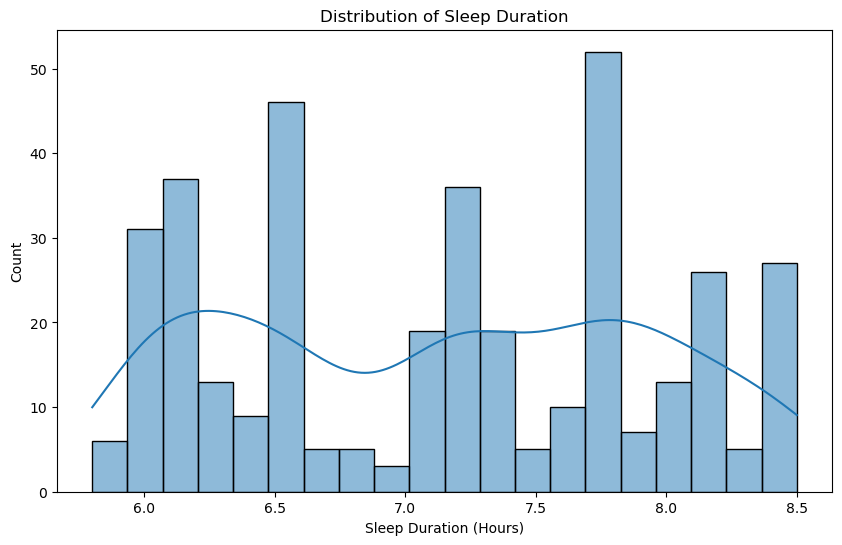

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['Sleep Duration'], kde=True, bins=20)
plt.title("Distribution of Sleep Duration")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Count")
plt.show()

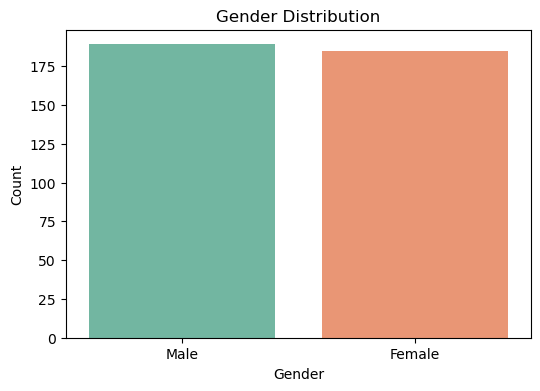

In [14]:
# gender distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

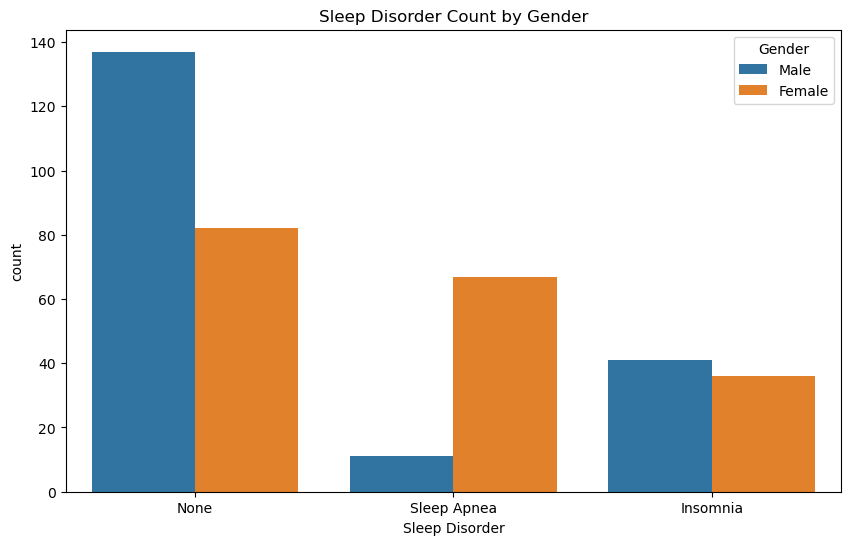

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(x='Sleep Disorder', hue='Gender', data=df)
plt.title("Sleep Disorder Count by Gender")
plt.show()

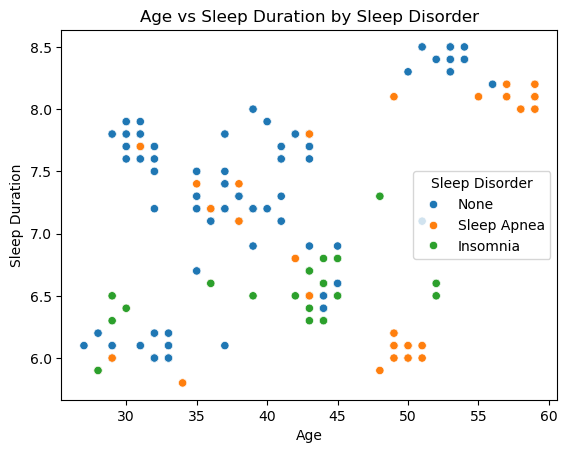

In [18]:
sns.scatterplot(x='Age', y='Sleep Duration', hue='Sleep Disorder', data=df)
plt.title("Age vs Sleep Duration by Sleep Disorder")
plt.show()

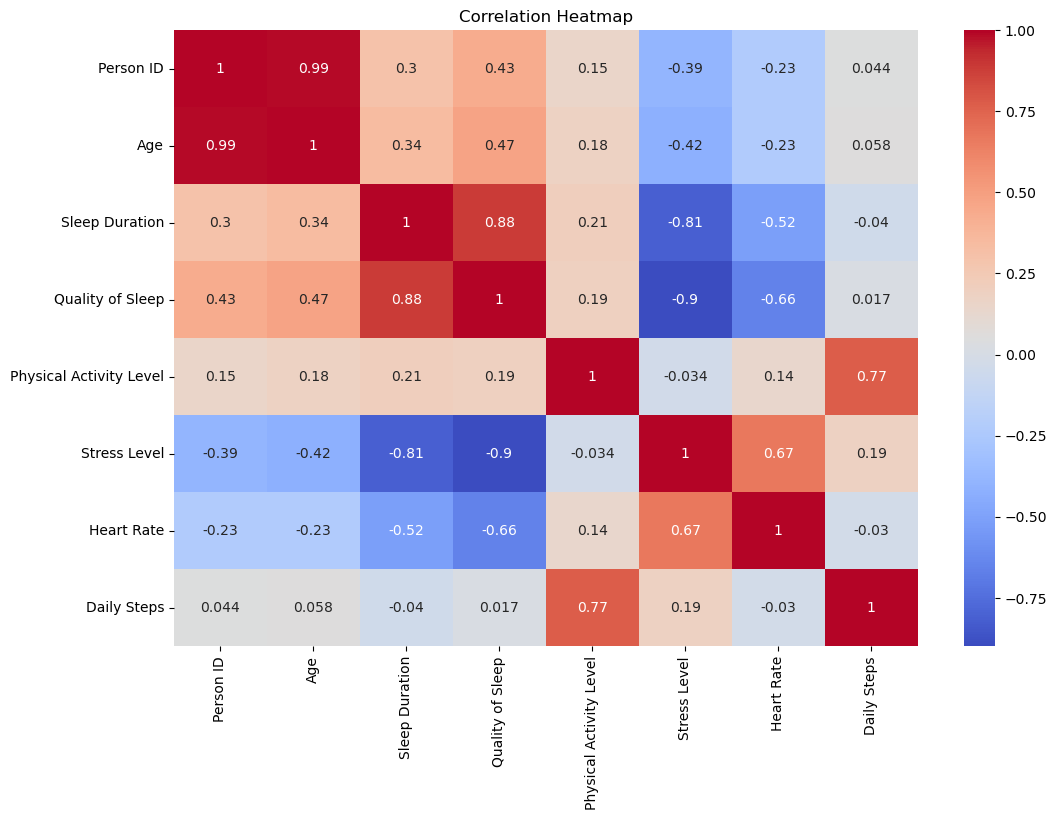

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)


numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", numerical_cols)

Categorical columns: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']
Numerical columns: ['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']


In [21]:
df[numerical_cols].describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


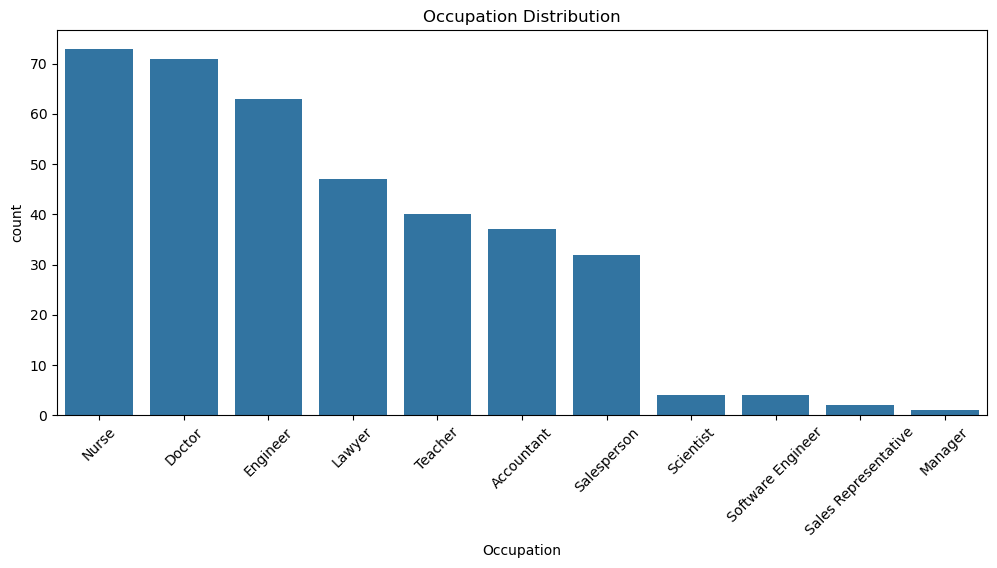

In [22]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Occupation', order=df['Occupation'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Occupation Distribution")
plt.show()

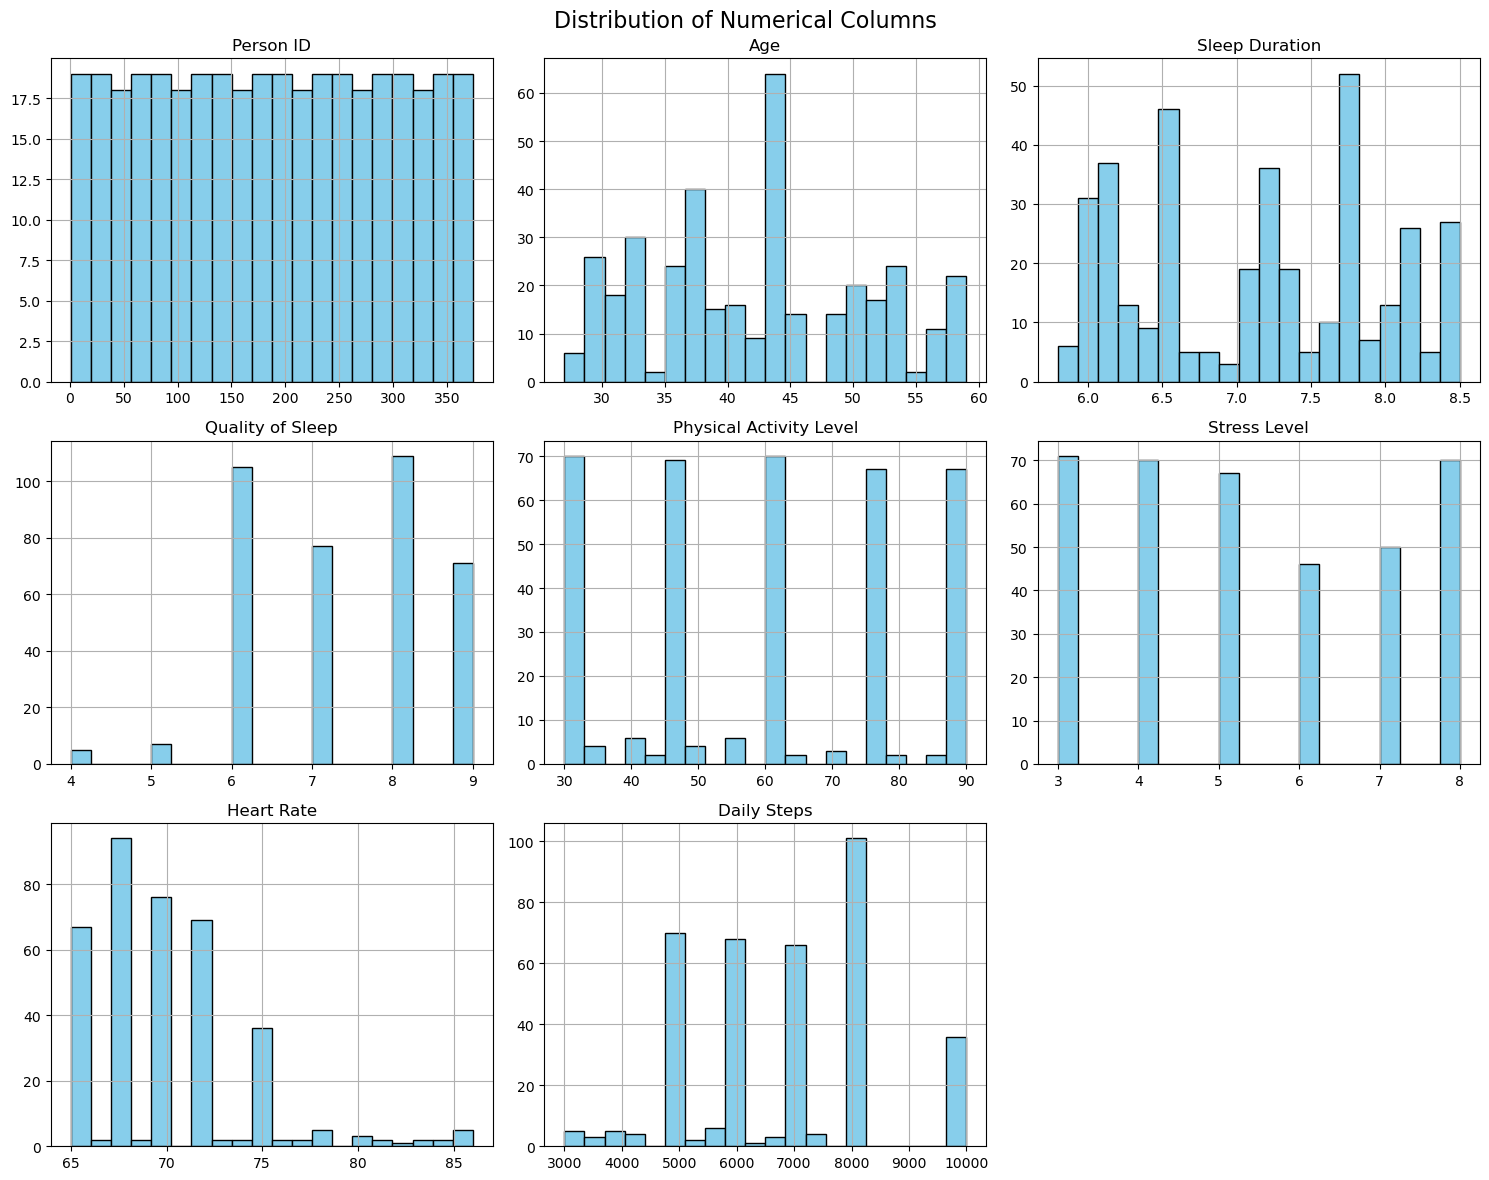

In [23]:
df.hist(figsize=(15, 12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Columns", fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
df_model = df[df['Sleep Disorder'].notna()].copy()

y = df_model['Sleep Disorder']

X = df_model.drop(columns=['Person ID', 'Sleep Disorder', 'Blood Pressure', 'BMI Category', 'Occupation', 'Gender'])

In [26]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Gender', 'Occupation', 'BMI Category']
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

In [27]:
X = df_model[['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
              'Stress Level', 'Heart Rate', 'Daily Steps']]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Insomnia       0.81      0.81      0.81        16
        None       0.91      0.98      0.94        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.86      0.83      0.84        75
weighted avg       0.88      0.88      0.88        75



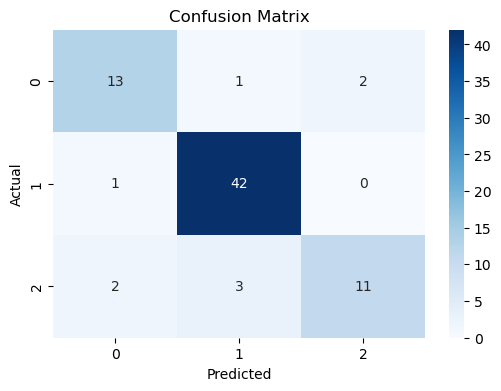

In [30]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.49767263 0.26046992]


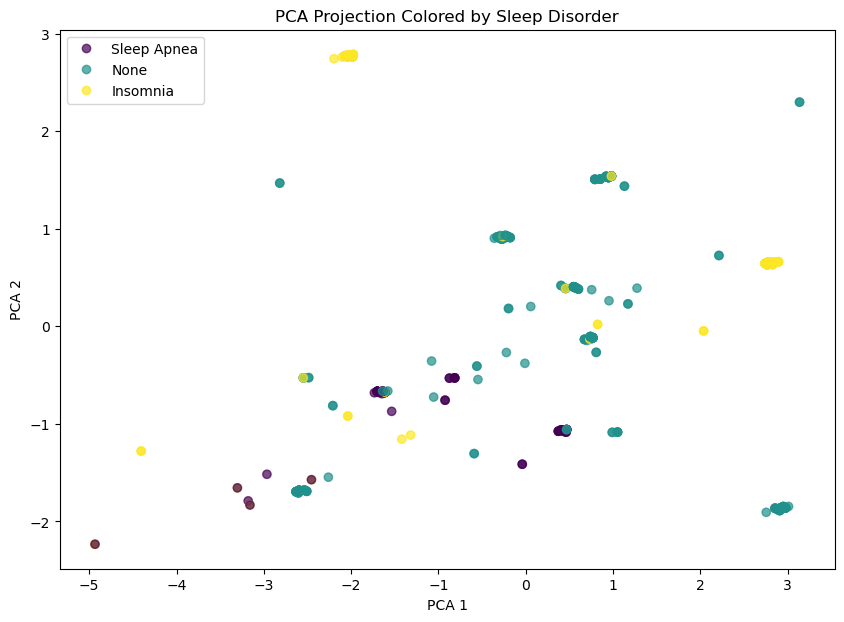

In [33]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=LabelEncoder().fit_transform(y), cmap='viridis', alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA Projection Colored by Sleep Disorder')
plt.legend(handles=scatter.legend_elements()[0], labels=set(y))
plt.show()

In [37]:
from sklearn.metrics import silhouette_score
for k in range(2,8):
    km = KMeans(n_clusters = k, random_state = 42)
    labels = km.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    print(f'For n_clusters = {k}, silhouette score is {sil_score}')

For n_clusters = 2, silhouette score is 0.36962369156040725
For n_clusters = 3, silhouette score is 0.45319688438994354
For n_clusters = 4, silhouette score is 0.5030983402766349
For n_clusters = 5, silhouette score is 0.4738227937416808
For n_clusters = 6, silhouette score is 0.4713292443844556
For n_clusters = 7, silhouette score is 0.4803330694097608


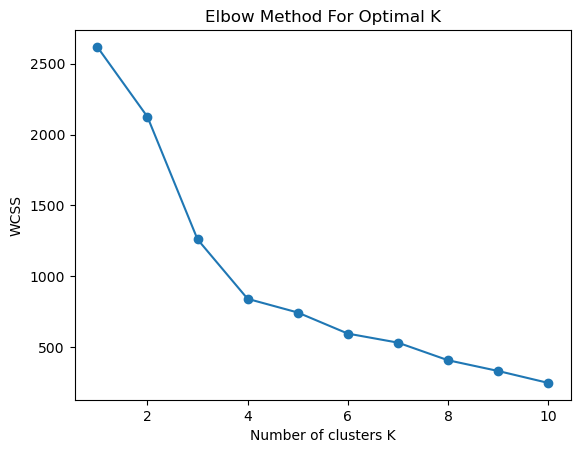

In [38]:
wcss = []
K = range(1,11)
for k in K:
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
plt.plot(K, wcss, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters K')
plt.ylabel('WCSS')
plt.show()

In [41]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
print(df.head())

   Person ID Gender  Age  ... Sleep Disorder  cluster  Cluster
0          1   Male   27  ...           None        0        2
1          2   Male   28  ...           None        1        1
2          3   Male   28  ...           None        1        1
3          4   Male   28  ...    Sleep Apnea        1        2
4          5   Male   28  ...    Sleep Apnea        1        2

[5 rows x 15 columns]


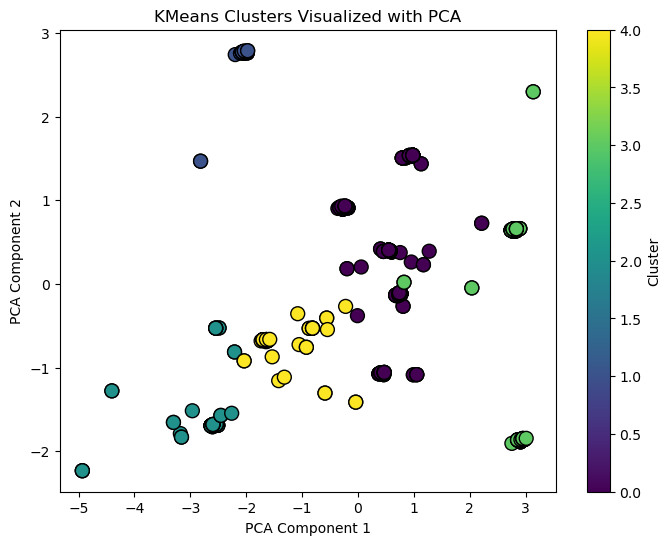

In [42]:
#visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', marker='o', edgecolor='k', s=100)
plt.title('KMeans Clusters Visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()